In [1]:
import os

output_folder = r"D:\processed"

os.makedirs(output_folder, exist_ok=True)

In [2]:
import os
import pickle
import pandas as pd

root = r"D:\all"
output_root = r"D:\processed"

os.makedirs(output_root, exist_ok=True)

for scene in sorted(os.listdir(root)):

    scene_path = os.path.join(root, scene)

    if not os.path.isdir(scene_path):
        continue

    lidar_path = os.path.join(scene_path, "lidar")

    if not os.path.exists(lidar_path):
        continue

    output_scene = os.path.join(output_root, scene)
    os.makedirs(output_scene, exist_ok=True)

    print(f"Processing Scene {scene}")

    for file in sorted(os.listdir(lidar_path)):

        if not file.endswith(".pkl"):
            continue

        pkl_file = os.path.join(lidar_path, file)

        with open(pkl_file, "rb") as f:
            df = pickle.load(f)

        # Add identifiers
        df["scene"] = scene
        df["frame"] = file[:-4]

        parquet_name = file.replace(".pkl", ".parquet")

        df.to_parquet(
            os.path.join(output_scene, parquet_name),
            index=False
        )

print("Finished Successfully!")

Processing Scene 001
Processing Scene 002
Processing Scene 003
Processing Scene 004
Processing Scene 005
Processing Scene 006
Processing Scene 008
Processing Scene 011
Processing Scene 012
Processing Scene 013
Processing Scene 014
Processing Scene 015
Processing Scene 016
Processing Scene 017
Processing Scene 018
Processing Scene 019
Processing Scene 020
Processing Scene 021
Processing Scene 023
Processing Scene 024
Processing Scene 027
Processing Scene 028
Processing Scene 029
Processing Scene 030
Processing Scene 032
Processing Scene 033
Processing Scene 034
Processing Scene 035
Processing Scene 037
Processing Scene 038
Processing Scene 039
Processing Scene 040
Processing Scene 041
Processing Scene 042
Processing Scene 043
Processing Scene 044
Processing Scene 045
Processing Scene 046
Processing Scene 047
Finished Successfully!


In [3]:
import pandas as pd

df = pd.read_parquet(r"D:\processed\013\00.parquet")

print(df.head())

           x           y         z      i             t  d scene frame
0  21.781174 -150.129745  1.891653  255.0  1.557541e+09  0   013    00
1   4.461189  -30.772923  0.779550    1.0  1.557541e+09  0   013    00
2   4.301026  -29.718597  0.293019    2.0  1.557541e+09  0   013    00
3   4.310325  -29.838099 -0.239449    2.0  1.557541e+09  0   013    00
4   3.852555  -26.705988 -0.486000    4.0  1.557541e+09  0   013    00


In [4]:
import os
import pandas as pd

scene_folder = r"D:\processed\013"

dfs = []

for file in sorted(os.listdir(scene_folder)):
    if file.endswith(".parquet"):
        dfs.append(pd.read_parquet(os.path.join(scene_folder, file)))

scene_df = pd.concat(dfs, ignore_index=True)

print(scene_df.shape)

(13113181, 8)


In [5]:
import dask.dataframe as dd

df = dd.read_parquet(r"D:\processed\**\*.parquet")

print(df.head())
print(df.columns)

           x          y         z     i             t  d scene frame
0 -58.457199 -61.269268  2.881014  39.0  1.557540e+09  0   001    00
1 -71.572182 -74.840317  1.279183   9.0  1.557540e+09  0   001    00
2 -42.442833 -44.357426  0.426503  56.0  1.557540e+09  0   001    00
3 -31.749357 -33.156342 -0.025245   3.0  1.557540e+09  0   001    00
4  -9.920758 -10.442794  1.010120   0.0  1.557540e+09  0   001    00
Index(['x', 'y', 'z', 'i', 't', 'd', 'scene', 'frame'], dtype='str')


In [6]:
scene13 = df[df.scene == "013"]
scene13

,x,y,z,i,t,d,scene,frame
npartitions=3120,,,,,,,,
,float64,float64,float64,float64,float64,int64,string,string
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [7]:
scene13_pd = scene13.compute()
scene13_pd

,x,y,z,i,t,d,scene,frame
0,21.781174,-150.129745,1.891653,255.0,1.557541e+09,0,013,00
1,4.461189,-30.772923,0.779550,1.0,1.557541e+09,0,013,00
2,4.301026,-29.718597,0.293019,2.0,1.557541e+09,0,013,00
3,4.310325,-29.838099,-0.239449,2.0,1.557541e+09,0,013,00
4,3.852555,-26.705988,-0.486000,4.0,1.557541e+09,0,013,00
...,...,...,...,...,...,...,...,...
159121,-7.675287,137.777556,5.808678,19.0,1.557541e+09,1,013,79
159122,-7.761000,137.784576,5.796234,25.0,1.557541e+09,1,013,79
159123,-7.840864,137.779617,5.783955,25.0,1.557541e+09,1,013,79
159124,-7.935958,137.747621,5.767704,23.0,1.557541e+09,1,013,79


In [8]:
import os
import pandas as pd

scene = "013"
folder = rf"D:\processed\{scene}"

dfs = []

for file in os.listdir(folder):
    if file.endswith(".parquet"):
        dfs.append(pd.read_parquet(os.path.join(folder, file)))

scene_df = pd.concat(dfs, ignore_index=True)

print(scene_df.shape)

(13113181, 8)


In [9]:
import os
import pandas as pd

scene = "013"
folder = rf"D:\processed\{scene}"

dfs = []

for file in os.listdir(folder):
    if file.endswith(".parquet"):
        dfs.append(pd.read_parquet(os.path.join(folder, file)))

scene_df = pd.concat(dfs, ignore_index=True)

print(scene_df.shape)

(13113181, 8)


In [10]:
class LidarDataset:
    def __init__(self, root):
        self.files = glob.glob(root + "/**/*.parquet", recursive=True)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        return pd.read_parquet(self.files[idx])

In [11]:
dfs

[                x           y          z      i             t  d scene frame
 0       21.781174 -150.129745   1.891653  255.0  1.557541e+09  0   013    00
 1        4.461189  -30.772923   0.779550    1.0  1.557541e+09  0   013    00
 2        4.301026  -29.718597   0.293019    2.0  1.557541e+09  0   013    00
 3        4.310325  -29.838099  -0.239449    2.0  1.557541e+09  0   013    00
 4        3.852555  -26.705988  -0.486000    4.0  1.557541e+09  0   013    00
 ...           ...         ...        ...    ...           ... ..   ...   ...
 168310 -17.862430   28.685167   5.398872    6.0  1.557541e+09  1   013    00
 168311   7.445382   70.768652   6.520636    2.0  1.557541e+09  1   013    00
 168312 -15.325797   63.856702   7.856923    3.0  1.557541e+09  1   013    00
 168313 -22.640937   35.953276   6.439409    2.0  1.557541e+09  1   013    00
 168314 -20.760269   86.669125  10.177863    5.0  1.557541e+09  1   013    00
 
 [168315 rows x 8 columns],
                 x           y    

In [12]:
scene_df

,x,y,z,i,t,d,scene,frame
0,21.781174,-150.129745,1.891653,255.0,1.557541e+09,0,013,00
1,4.461189,-30.772923,0.779550,1.0,1.557541e+09,0,013,00
2,4.301026,-29.718597,0.293019,2.0,1.557541e+09,0,013,00
3,4.310325,-29.838099,-0.239449,2.0,1.557541e+09,0,013,00
4,3.852555,-26.705988,-0.486000,4.0,1.557541e+09,0,013,00
...,...,...,...,...,...,...,...,...
13113176,-7.675287,137.777556,5.808678,19.0,1.557541e+09,1,013,79
13113177,-7.761000,137.784576,5.796234,25.0,1.557541e+09,1,013,79
13113178,-7.840864,137.779617,5.783955,25.0,1.557541e+09,1,013,79
13113179,-7.935958,137.747621,5.767704,23.0,1.557541e+09,1,013,79


In [14]:
import os
import gc
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from scipy.spatial import cKDTree

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

In [15]:
scene_df

,x,y,z,i,t,d,scene,frame
0,21.781174,-150.129745,1.891653,255.0,1.557541e+09,0,013,00
1,4.461189,-30.772923,0.779550,1.0,1.557541e+09,0,013,00
2,4.301026,-29.718597,0.293019,2.0,1.557541e+09,0,013,00
3,4.310325,-29.838099,-0.239449,2.0,1.557541e+09,0,013,00
4,3.852555,-26.705988,-0.486000,4.0,1.557541e+09,0,013,00
...,...,...,...,...,...,...,...,...
13113176,-7.675287,137.777556,5.808678,19.0,1.557541e+09,1,013,79
13113177,-7.761000,137.784576,5.796234,25.0,1.557541e+09,1,013,79
13113178,-7.840864,137.779617,5.783955,25.0,1.557541e+09,1,013,79
13113179,-7.935958,137.747621,5.767704,23.0,1.557541e+09,1,013,79


In [16]:
scene_df.head()

,x,y,z,i,t,d,scene,frame
0,21.781174,-150.129745,1.891653,255.0,1.557541e+09,0,013,00
1,4.461189,-30.772923,0.779550,1.0,1.557541e+09,0,013,00
2,4.301026,-29.718597,0.293019,2.0,1.557541e+09,0,013,00
3,4.310325,-29.838099,-0.239449,2.0,1.557541e+09,0,013,00
4,3.852555,-26.705988,-0.486000,4.0,1.557541e+09,0,013,00


In [17]:
print("Dataset shape:", scene_df.shape)

Dataset shape: (13113181, 8)


In [18]:
print(scene_df.columns)

Index(['x', 'y', 'z', 'i', 't', 'd', 'scene', 'frame'], dtype='str')


In [19]:
scene_df = scene_df.copy()

scene_df["x"] = scene_df["x"].astype("float32")
scene_df["y"] = scene_df["y"].astype("float32")
scene_df["z"] = scene_df["z"].astype("float32")

scene_df["i"] = scene_df["i"].astype("float32")

scene_df["t"] = scene_df["t"].astype("float32")

scene_df["d"] = scene_df["d"].astype("int8")

scene_df["scene"] = scene_df["scene"].astype("category")

scene_df["frame"] = scene_df["frame"].astype("int16")

In [20]:
print(scene_df.info(memory_usage="deep"))

<class 'pandas.DataFrame'>
RangeIndex: 13113181 entries, 0 to 13113180
Data columns (total 8 columns):
 #   Column  Dtype   
---  ------  -----   
 0   x       float32 
 1   y       float32 
 2   z       float32 
 3   i       float32 
 4   t       float32 
 5   d       int8    
 6   scene   category
 7   frame   int16   
dtypes: category(1), float32(5), int16(1), int8(1)
memory usage: 300.1 MB
None


In [21]:
print("Missing values:")
print(scene_df.isnull().sum())

Missing values:
x        0
y        0
z        0
i        0
t        0
d        0
scene    0
frame    0
dtype: int64


In [22]:
scene_df = scene_df.dropna(
    subset=["x", "y", "z", "i"]
).reset_index(drop=True)

In [23]:
before = len(scene_df)

scene_df = scene_df.drop_duplicates(
    subset=["x", "y", "z"]
).reset_index(drop=True)

after = len(scene_df)

print("Duplicate points removed:", before - after)

Duplicate points removed: 0


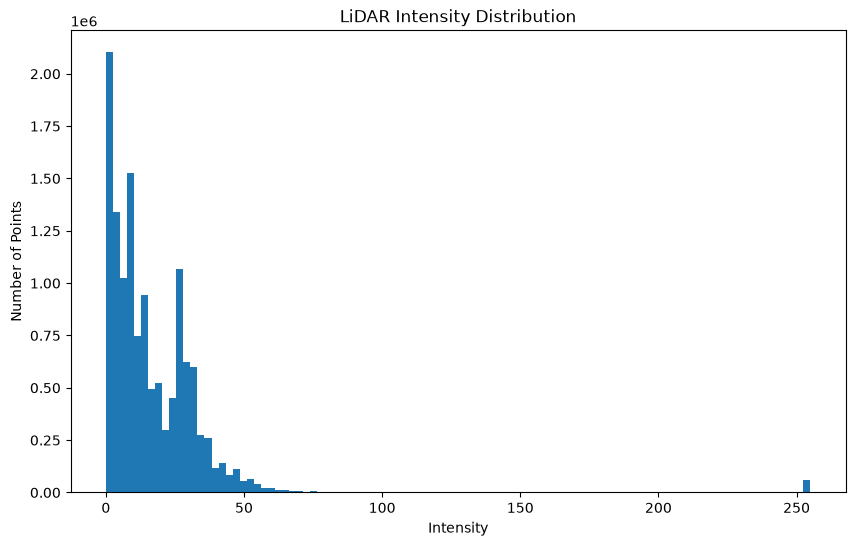

In [24]:
plt.figure(figsize=(10, 6))

plt.hist(
    scene_df["i"],
    bins=100
)

plt.title("LiDAR Intensity Distribution")
plt.xlabel("Intensity")
plt.ylabel("Number of Points")

plt.show()

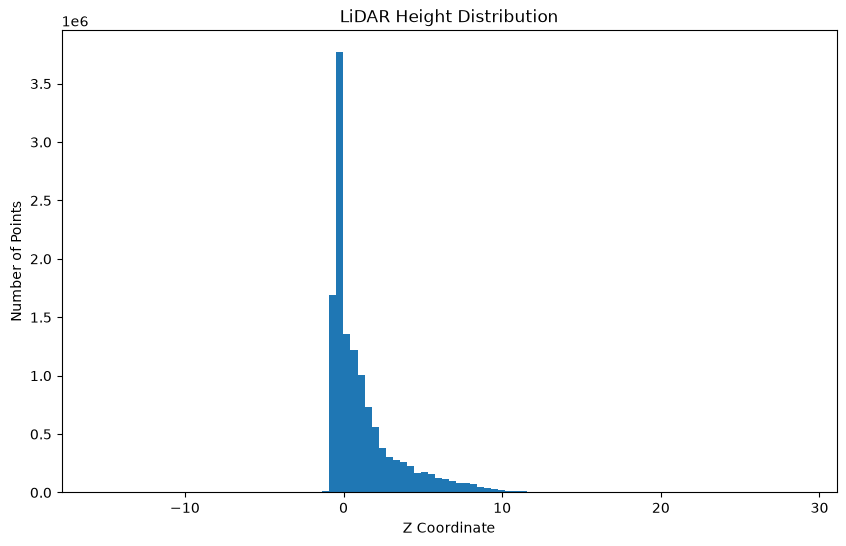

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(
    scene_df["z"],
    bins=100
)

plt.title("LiDAR Height Distribution")
plt.xlabel("Z Coordinate")
plt.ylabel("Number of Points")

plt.show()

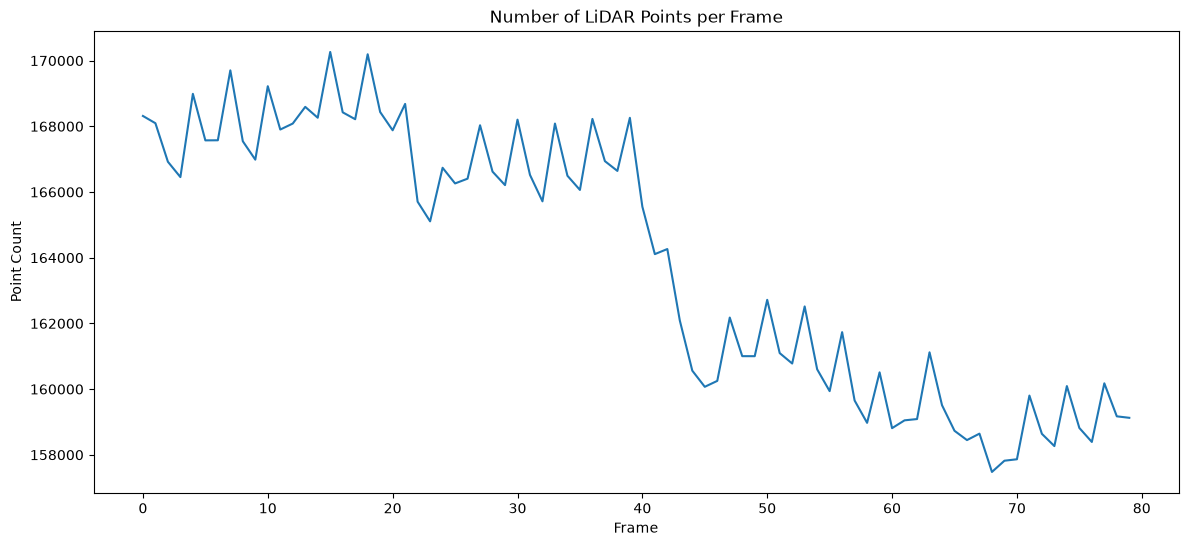

In [26]:
frame_counts = scene_df["frame"].value_counts().sort_index()

plt.figure(figsize=(14, 6))

plt.plot(
    frame_counts.index,
    frame_counts.values
)

plt.title("Number of LiDAR Points per Frame")
plt.xlabel("Frame")
plt.ylabel("Point Count")

plt.show()

In [27]:
SAMPLE_SIZE = 100_000

sample_df = scene_df.sample(
    n=min(SAMPLE_SIZE, len(scene_df)),
    random_state=42
)

In [ ]:
points = sample_df[["x", "y", "z"]].values.astype(np.float64)
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

In [ ]:
o3d.visualization.draw_geometries([pcd],window_name="Original LiDAR Point Cloud")